### Приветствую, соискатель!
Ниже представлено задание, которое выявляет твои способности ориентироваться в предметной области, добывать информацию, пользоваться инструментарием и делать выводы, основываясь на данных.
В реальной жизни мы ожидаем что сотрудник справится с подобным заданием за 1 рабочий день и сделает его вдумчиво и тщательно.
На этапе тестирования мы не ожидаем максимальной проработки и не ограничиваем тебя по времени. Делай так как считаешь нужным, чтобы мы сформировали представление о твоем опыте и навыках.

#### **Задание**

Основываясь на истории транзакций адреса 0x99FD1378ca799ED6772Fe7bCDC9B30B389518962 полученных из  Etherscan https://etherscan.io/address/0x99fd1378ca799ed6772fe7bcdc9b30b389518962 

Проанализируй и опиши финансовую стратегию этого адреса.

Ожидаемый результат: сценарий получения и анализа данных и небольшой аналитический обзор.

Допускается использование любых инструментов: библиотек python или внешних сервисов, например Dune Analytics https://dune.xyz

## Data
simply download csv file to take a look at the data from there, Etherscan allows to download 5000 transactions as csv  
there are 7911 transactions in total for that account, therefore we will download 2 files:
1.  very beginning - 2021-05-31
2. 2021-06-01 - till today

we could also use API, and we will, but for the current task it is more convenient to simply download csv file

In [49]:
import pandas as pd
import numpy as np

In [50]:
df_1 = pd.read_csv('./data/user_data_1.csv')
df_2 = pd.read_csv('./data/user_data_2.csv')

In [51]:
number_rows_1 = len(df_1)
print(f'number of rows in first part of data: {number_rows_1}')

number_rows_2 = len(df_2)
print(f'number of rows in second part of data: {number_rows_2}')

df = pd.concat([df_1, df_2]).reset_index(drop=True)
total_number_rows = len(df)
print(f'total number of rows {total_number_rows}')

number of rows in first part of data: 4125
number of rows in second part of data: 3788
total number of rows 7913


Get data from API:

In [52]:
import requests
import certifi

import os
from dotenv import load_dotenv
load_dotenv()
access_token = os.getenv('MY_ACCESS_TOKEN')

In [53]:
#Get a list of 'Normal' Transactions By Address
addess = '0x99FD1378ca799ED6772Fe7bCDC9B30B389518962'
number_of_transactions = 10000

url = "https://api.etherscan.io/api" + \
      "?module=account" + \
      "&action=txlist" + \
      "&address=" + addess + \
      "&startblock=0" + \
      "&endblock=9999999999999999" + \
      "&page=1" + \
      "&offset=" + str(number_of_transactions) + \
      "&sort=asc" + \
      "&apikey=" + access_token

response = requests.get(url, verify=certifi.where())
address_content = response.json()

In [54]:
number_of_rows_from_API = len(address_content['result'])
print(f'number of rows from API request: {number_of_rows_from_API}')

number of rows from API request: 7927


In [55]:
# create empty dataframe to then will it with the data:
df_test = pd.DataFrame(address_content['result'][0], index=[0])
df_base = df_test.drop(index=0)

# add data row by row to the dataframe:
for i in range (0, number_of_rows_from_API):
    df_iter = pd.DataFrame(address_content['result'][i], index=[0])
    df_base = pd.concat([df_base, df_iter]).reset_index(drop=True)

# data from api, we will use it to compare result and additionally check
df_api = df_base.copy()
df_api.to_csv('./data/data_api.csv')

We get the same number of rows, therefore we can use either data set, for now we will use dataset from CSV file downloaded from Etherscan, since it has adopted data (datetime columns and methods) and we do not have to merge it (methods) from other requests, but we obviously Can :)   
 
on the current stage we fixed amount of data

In [56]:
df.columns

Index(['Txhash', 'Blockno', 'UnixTimestamp', 'DateTime', 'From', 'To',
       'ContractAddress', 'Value_IN(ETH)', 'Value_OUT(ETH)',
       'CurrentValue @ $1084.99/Eth', 'TxnFee(ETH)', 'TxnFee(USD)',
       'Historical $Price/Eth', 'Status', 'ErrCode', 'Method', 'empty',
       'CurrentValue @ $1103.42/Eth'],
      dtype='object')

#### Columns description:
- Txhash - Transaction Hash: A unique identifier that can be used to locate a specific transaction
- Blockno - Block: The block number that the transaction was included in.
- UnixTimestamp - Timestamp: The time that the block was mined in UTC.
- DateTime - date and time of transaction  
- From - From: The account that originally sent the transaction.   
- To - To: The account that the transaction is addressed to.  
- ContractAddress - ?  
- Value_IN(ETH) - amount of ETH that transfered to the account of interest ("user_1")  
- Value_OUT(ETH) - amount of ETH that tranfered from the account of interest ("user_1")  
- CurrentValue @ $1098.81/Eth - Value of transaction in USD according to the current price  
- TxnFee(ETH) - Transaction Fee: The amount of Ether paid to the miner for processing the transaction, which is calculated by multiplying the amount of gas used by the gas price.  
- TxnFee(USD) - transaction fee in USD  
- Historical $Price/Eth - Price of USD/ETH price at the moment of transaction  
- Status - Status: The current state of a transaction (Success, Failed, or Pending).  
- ErrCode - code of error
- Method - type of transaction

In [57]:
# fix: columns Change error_code and status:

# new column "error_code":
df['error_code'] = df['Status']
# new column 'status':
df['status'] = df['ErrCode']

# drop old columns:
df = df.drop(columns=['ErrCode', 'Status', 'empty'])

In [58]:
df.columns

Index(['Txhash', 'Blockno', 'UnixTimestamp', 'DateTime', 'From', 'To',
       'ContractAddress', 'Value_IN(ETH)', 'Value_OUT(ETH)',
       'CurrentValue @ $1084.99/Eth', 'TxnFee(ETH)', 'TxnFee(USD)',
       'Historical $Price/Eth', 'Method', 'CurrentValue @ $1103.42/Eth',
       'error_code', 'status'],
      dtype='object')

In [59]:
# look at the method column:

methods = list(df['Method'].unique())
for method in methods:
    if method[0:2] == '0x':
        print(method)

0x4e7ffa04
0xf4378240
0x3ca9184e
0x6d24fb96
0x86b2ecc4
0xe2b39746
0x415565b0
0x2da62987
0xac95ea74
0x90411a32
0x7c025200
0xafc6728e
0x77725df6
0x7a1eb1b9
0x0f3b31b2
0x68747470
0xaa77476c


Some values in column Method does not look like Types of transactions,  
they look more like error code,  
- so we change values in such rows to 'error' in Method column
- and store values of this errors in error_code column  
- we will lost Error(0) code in error_code column (we could keep it, but it will not affect the analysis, since it is 100% the same as "Reverted" status)

In [60]:
# function to fill error_code column:
def check_error_code(value):
    result = np.nan
    if value[0:2] == '0x': # return error codes
        result = value
    return result

# function to fill Method column
def check_method(value):
    result = np.nan
    if value[0:2] != '0x': # return only methods
        result = value
    return result


# apply to error_code column:
df['error_code'] = df['Method'].apply(lambda x: check_error_code(x))
# apply to method column:
df['Method'] = df['Method'].apply(lambda x: check_method(x))

In [61]:
# types of data in fields:
df.dtypes

Txhash                          object
Blockno                          int64
UnixTimestamp                    int64
DateTime                        object
From                            object
To                              object
ContractAddress                float64
Value_IN(ETH)                  float64
Value_OUT(ETH)                 float64
CurrentValue @ $1084.99/Eth    float64
TxnFee(ETH)                    float64
TxnFee(USD)                    float64
Historical $Price/Eth          float64
Method                          object
CurrentValue @ $1103.42/Eth    float64
error_code                      object
status                          object
dtype: object

In [62]:
user_1 = df['From'].unique()[1]
user_1

'0x99fd1378ca799ed6772fe7bcdc9b30b389518962'

In [63]:
total_n_rows = len(df)
print(f'total number of rows in dataset: {len(df)}')

rows_n_user_1_sender = len(df[df['From'] == user_1])
share_sender = round(rows_n_user_1_sender / total_n_rows * 100, 2)
print(f'rows where user_1 is sender: {rows_n_user_1_sender}, which is {share_sender}%')

rows_n_user_1_receiver = len(df[df['To'] == user_1])
share_receiver = round(rows_n_user_1_receiver / total_n_rows * 100, 2)
print(f'rows where user_1 reseives: {rows_n_user_1_receiver}, which is {share_receiver}%')

check_sum = rows_n_user_1_receiver + rows_n_user_1_sender
print()
print(f'Check: sum rows and send rows receive: {check_sum}')


total number of rows in dataset: 7913
rows where user_1 is sender: 7579, which is 95.78%
rows where user_1 reseives: 367, which is 4.64%

Check: sum rows and send rows receive: 7946


So, it looks like that Majority of transactions are From accoung of user_1  
but the total sum of rows is lower then sume of rows (sender+receiver), it may be so if in some rows user is sender and receiver at the same time:

In [64]:
df[(df['From'] == user_1) & (df['To'] == user_1)].head(2)

,Txhash,Blockno,UnixTimestamp,DateTime,From,To,ContractAddress,Value_IN(ETH),Value_OUT(ETH),CurrentValue @ $1084.99/Eth,TxnFee(ETH),TxnFee(USD),Historical $Price/Eth,Method,CurrentValue @ $1103.42/Eth,error_code,status
198,0x07a8cf795718de77a6f6cc1dacd0d4f02607c1a819b8...,10765398,1598832885,2020-08-31 00:14:45,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,NaN,0.0,0.0,0.0,0.002772,3.007592,434.10,Transfer,NaN,NaN,NaN
257,0x44e51913d36da6b91ec2d123e051b01ef2e00212f1f8...,10782426,1599057570,2020-09-02 14:39:30,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,NaN,0.0,0.0,0.0,0.013020,14.126570,439.83,Transfer,NaN,NaN,NaN


there are indeed such transactions

In [65]:
rows_n_receiver_and_sender = len(df[(df['From'] == user_1) & (df['To'] == user_1)])
print(f'number of rows where user_1 is receiver and sender simulateously: {rows_n_receiver_and_sender}')

diff_between_sum_send_receive_and_total = check_sum - total_n_rows
print(f'difference between total number of rows and sum of sender and receiver rows: {diff_between_sum_send_receive_and_total}')

number of rows where user_1 is receiver and sender simulateously: 33
difference between total number of rows and sum of sender and receiver rows: 33


these numbers are exactly match, therefore we can find the following statistics:

In [66]:
total_n_rows = len(df)
print(f'total number of rows in dataset: {len(df)}')

rows_n_user_1_sender = len(df[(df['From'] == user_1) & (df['To'] != user_1)] ) # only sender not receiver
share_sender = round(rows_n_user_1_sender / total_n_rows * 100, 2)
print(f'rows where user_1 is sender: {rows_n_user_1_sender}, which is {share_sender}%')

rows_n_user_1_receiver = len(df[(df['To'] == user_1) & (df['From'] != user_1)]) # only receiver not sender
share_receiver = round(rows_n_user_1_receiver / total_n_rows * 100, 2)
print(f'rows where user_1 reseives: {rows_n_user_1_receiver}, which is {share_receiver}%')

rows_n_receiver_and_sender = len(df[(df['From'] == user_1) & (df['To'] == user_1)])
share_send_receive_sim = round( rows_n_receiver_and_sender / total_n_rows * 100, 2  )
print(f'number of rows where user_1 is receiver and sender simulateously: {rows_n_receiver_and_sender}, which is {share_send_receive_sim}%')

check_sum = rows_n_user_1_receiver + rows_n_user_1_sender + rows_n_receiver_and_sender
check_sum_precentage = share_sender + share_receiver + share_send_receive_sim
print()
print(f'Check: sum rows and send rows receive: {check_sum}, sum of percentage: {check_sum_precentage} %')

total number of rows in dataset: 7913
rows where user_1 is sender: 7546, which is 95.36%
rows where user_1 reseives: 334, which is 4.22%
number of rows where user_1 is receiver and sender simulateously: 33, which is 0.42%

Check: sum rows and send rows receive: 7913, sum of percentage: 100.0 %


##### Values in USD
Now, let us calculate Actual Values of Transactions in USD, to do that we will convert ETH to USD based on historical Exchage rate

but before, find how many Rate values are Empty:

In [67]:
empty_rows_exhange_rate = len(df[df['Historical $Price/Eth'].isna()])
print(f'number of rows with empty Historical Rate: {empty_rows_exhange_rate}')

empty_rows_value_in = len(df[df['Value_IN(ETH)'].isna()])
print(f'number of empty rows Value_IN: {empty_rows_value_in}')

empty_rows_value_out = len(df[df['Value_OUT(ETH)'].isna()])
print(f'number of empty rows Value_OUT: {empty_rows_value_out}')

number of rows with empty Historical Rate: 2
number of empty rows Value_IN: 0
number of empty rows Value_OUT: 0


If there would be any rows with empty Historical data, it could occur in transaction of current date, for that cases, fill such cells with current price

In [68]:
current_price = float(df.columns[9][16:23])
df.loc[df['Historical $Price/Eth'].isna(), 'Historical $Price/Eth'] = current_price
print(f'current price: {current_price} usd/eth')

current price: 1084.99 usd/eth


In [69]:
# create calculated fields Actual amount in USD:
df['Value_IN(USD)'] = df['Value_IN(ETH)'] * df['Historical $Price/Eth']
df['Value_OUT(USD)'] = df['Value_OUT(ETH)'] * df['Historical $Price/Eth']

Look at totals: (we consider rows where address is receiver and sender simultaneously twice, in 2 cases it is big values, so we should be aware of that, so we will not consider those rows, since they influence only by Transaction fee on balance)

! It is important to note that here we did not filtered Reverted transactions, since they do not have too much influence on the total picutre, but it is important to remember  
we will filter such transactions in Tableau later

In [70]:
df_send = df[(df['From'] == user_1) & (df['To'] != user_1)]
df_receive = df[(df['To'] == user_1) & (df['From'] != user_1)]

sum_value_in = round(df_receive['Value_IN(ETH)'].sum(), 2)
sum_value_out = round(df_send['Value_OUT(ETH)'].sum(), 2)
margin_total = sum_value_in - sum_value_out

print(f'Total IN = {sum_value_in} ETH, Total OUT = {sum_value_out} ETH, Total Margin = {margin_total} ETH')

Total IN = 167320.61 ETH, Total OUT = 1337997.03 ETH, Total Margin = -1170676.42 ETH


by looking at the amount of ETH, it may seem like Outflow is greater then Inflow  
let's look at the amount in USD:

In [71]:
sum_value_in = round(df_receive['Value_IN(USD)'].sum(), 2)
sum_value_out = round(df_send['Value_OUT(USD)'].sum(), 2)
margin_total = sum_value_in - sum_value_out

print(f'Total IN = {sum_value_in} USD, Total OUT = {sum_value_out} USD, Total Margin = {margin_total} USD')

Total IN = 469072264.94 USD, Total OUT = 3091814686.31 USD, Total Margin = -2622742421.37 USD


Margin is also negative here  
For me it looks strange, since if we had all transactions, we would expect only 0 balance and not negative (in ETH), and we could expect negative balance in USD due to change Exchange rate, also, we did not consider transaction fees yet and they would have big effect on balance since transaction fees are high in Ethereum network

therefore, using Etherscan API, let's get Current Balance of the Address to check our results:

In [72]:
#Get Ether Balance for a Single Address
addess = '0x99FD1378ca799ED6772Fe7bCDC9B30B389518962'

url = "https://api.etherscan.io/api" + \
      "?module=account" + \
      "&action=balance" + \
      "&address=" + addess + \
      "&tag=latest" + \
      "&apikey=" + access_token

response = requests.get(url, verify=certifi.where())
latest_balance_data = response.json()

In [73]:
# 18 - is number of decimals (because ehtereum network does not work with decimals, all values are in Wei)
latest_balance = float(latest_balance_data['result']) / 10**18 
print(f'latest balance of user_1 address = {round(latest_balance, 3)} ETH')

latest balance of user_1 address = 39.064 ETH


Therefore, we can see that the Actual Ether balance is positive in the Address, therefore there are some data that we miss in the consideration

Lets take a look also on the earliest balance:

In [74]:
#Get Ether Balance for a Single Address
addess = '0x99FD1378ca799ED6772Fe7bCDC9B30B389518962'

url = "https://api.etherscan.io/api" + \
      "?module=account" + \
      "&action=balance" + \
      "&address=" + addess + \
      "&tag=earliest" + \
      "&apikey=" + access_token

response = requests.get(url, verify=certifi.where())
earliest_balance_data = response.json()

In [75]:
earliest_balance = float(earliest_balance_data['result']) / 10**18 
print(f'earliest balance of user_1 address = {round(earliest_balance, 3)} ETH')

earliest balance of user_1 address = 39.064 ETH


Greate! we can see that the very first balance was 0, which is logical

Our task is to understand the financial stategy of the Address

In [76]:
# save data for analysis
df.to_csv('./data/user_data_final.csv', sep=',')

In [77]:
df.columns

Index(['Txhash', 'Blockno', 'UnixTimestamp', 'DateTime', 'From', 'To',
       'ContractAddress', 'Value_IN(ETH)', 'Value_OUT(ETH)',
       'CurrentValue @ $1084.99/Eth', 'TxnFee(ETH)', 'TxnFee(USD)',
       'Historical $Price/Eth', 'Method', 'CurrentValue @ $1103.42/Eth',
       'error_code', 'status', 'Value_IN(USD)', 'Value_OUT(USD)'],
      dtype='object')

### General statistics

Lets find out with how many different account User_1 have transactions:

In [78]:
from_addresses = list(df['From'].unique())
from_addresses_len = len(from_addresses)

to_addresses = list(df['To'].unique())
to_addresses_len = len(to_addresses)

all_addresses = from_addresses.copy()
# check is address is not in list, add to have all contracts:
for address in to_addresses:
    if address not in all_addresses:
        all_addresses.append(address)
    
all_addresses_len = len(all_addresses)

print(f'number of unique addresses which send transactions to user: {from_addresses_len}')
print(f'number of unique transactions to which user send transactions: {to_addresses_len}')

print()
print(f'number of all unique addresses: {all_addresses_len}')
print(f'number of accounts that were in both senders and receivers: {from_addresses_len+to_addresses_len-all_addresses_len}')

number of unique addresses which send transactions to user: 54
number of unique transactions to which user send transactions: 396

number of all unique addresses: 444
number of accounts that were in both senders and receivers: 6


In [79]:
df_groupping = df.groupby(['From'], as_index=False).agg({
    'Value_IN(ETH)': sum,
    'Txhash': 'count'
}).sort_values(by='Value_IN(ETH)', ascending=False).head(10)
df_groupping.columns = ['address sender to user_1', 'sum_value(ETH)', 'number of transactions']
df_groupping

,address sender to user_1,sum_value(ETH),number of transactions
44,0xc098b2a3aa256d2140208c3de6543aaef5cd3a94,88839.387199,103
11,0x2a67035357c3045438f3a92e46870a9e48e5aab7,39566.761902,90
23,0x58f56615180a8eea4c462235d9e215f72484b4a3,16010.861660,7
38,0x937cdc9e86ba06aa5aaea221017a1d9fc7f59efd,10269.950000,41
42,0xab07bf2548bc22b9211469a11d09f83d26611d72,4544.608387,3
46,0xc333e80ef2dec2805f239e3f1e810612d294f771,1353.591500,8
18,0x3f5ce5fbfe3e9af3971dd833d26ba9b5c936f0be,1149.774050,1
17,0x3bf57ca56baba3bc357e055bcce48565d95a6906,1063.094002,1
33,0x7dac3ea4b99b15ec53cfa0f37510dd828b27895d,849.998577,1
27,0x679c686b4b6934007aeb54b3dfc4a59d52b4ee39,699.997995,1


these are to 10 accounts that sent ETH to User_1

In [80]:
df_groupping =  df.groupby(['To'], as_index=False).agg({
    'Value_OUT(ETH)': sum,
    'Txhash': 'count'
}).sort_values(by='Value_OUT(ETH)', ascending=False).head(10)
df_groupping.columns = ['address receiver from user_1', 'sum_value(ETH)', 'number of transactions']
df_groupping

,address receiver from user_1,sum_value(ETH),number of transactions
383,0xf859a1ad94bcf445a406b892ef0d3082f4174088,309054.265255,95
131,0x4ddc2d193948926d02f9b1fe9e1daa0718270ed5,258423.164458,325
175,0x67b66c99d3eb37fa76aa3ed1ff33e8e39f0b9c7a,238042.027574,70
232,0x92be6adb6a12da0ca607f9d87db2f9978cd6ec3e,153420.015707,76
354,0xdc24316b9ae028f1497c275eb9192a3ea0f67022,141689.241265,28
1,0x0074aa8dacc40ad79b12e5239a6fe6684fc876e9,68550.000000,37
235,0x937cdc9e86ba06aa5aaea221017a1d9fc7f59efd,44427.158799,36
372,0xeea3311250fe4c3268f8e684f7c87a82ff183ec1,20440.618597,8
395,0xff590dc002e305852179af8e3184d2f640c8362e,20000.000000,3
331,0xcc9a0b7c43dc2a5f023bb9b738e45b0ef6b06e04,17904.182312,4


And these are top 10 addresses that User_1 sent ETH to

Let's now look at basic statistics on Value of transactions of User:

Now compare that results to self-check on data from API

In [81]:
df_api.columns

Index(['blockNumber', 'timeStamp', 'hash', 'nonce', 'blockHash',
       'transactionIndex', 'from', 'to', 'value', 'gas', 'gasPrice', 'isError',
       'txreceipt_status', 'input', 'contractAddress', 'cumulativeGasUsed',
       'gasUsed', 'confirmations'],
      dtype='object')

In [82]:
df_sender = df_api[(df_api['from'] == user_1) & (df_api['to'] != user_1)].reset_index(drop=True)
df_receiver = df_api[(df_api['to'] == user_1) & (df_api['from'] != user_1)].reset_index(drop=True)
df_send_receive = df_api[(df_api['to'] == user_1) & (df_api['from'] == user_1)].reset_index(drop=True)

n_sender = len(df_sender)
n_receiver = len(df_receiver)
n_send_receive = len(df_send_receive)
print(f'n_sernder = {n_sender}')
print(f'n_receiver = {n_receiver}')
print(f'n_send_receive = {n_send_receive}')
print(f'total = {n_sender + n_receiver + n_send_receive}')

n_sernder = 7560
n_receiver = 334
n_send_receive = 33
total = 7927


number of rows the same, not lets look at the totals:

In [83]:
# pd.to_numerics failed on value column, so let's use custom function converting each element to int:
def to_interer(value):
    result = int(value) / 10**18 #convert to eth
    return result

# apply to value column:
df_sender['value(ETH)'] = df_sender['value'].apply(lambda x: to_interer(x))
df_receiver['value(ETH)'] = df_receiver['value'].apply(lambda x: to_interer(x))

In [84]:
value_in_total = round(df_receiver['value(ETH)'].sum(), 2)
value_out_total = round(df_sender['value(ETH)'].sum(), 2)
margin_api = value_in_total - value_out_total
print(f'value in: {value_in_total} ETH')
print(f'value out: {value_out_total} ETH')
print(f'margin: {margin_api} ETH')

value in: 167320.61 ETH
value out: 1342897.03 ETH
margin: -1175576.42 ETH


data 100% match, just in case, it is better check then not to check :)

In [85]:
import seaborn as sns
from scipy.stats import kurtosis
from scipy.stats import skew

In [86]:
# apply to integer function to whole df_api dataset:
df_api['value(ETH)'] = df_api['value'].apply(lambda x: to_interer(x))

In [87]:
def basic_research(df, col_name):
    print('basic metrics:')
    print(df[col_name].describe())
    print('-------------------------')

    
    print(f'Kurtosis (Эксцесс): {kurtosis(df[col_name])}')
    print(f'Skew (Ассиметрия): {skew(df[col_name])}')

    sns.displot(df[col_name])

basic metrics:
count     7927.000000
mean       190.515949
std       1543.647241
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      75980.000000
Name: value(ETH), dtype: float64
-------------------------
Kurtosis (Эксцесс): 889.1663806515936
Skew (Ассиметрия): 23.722916573459496


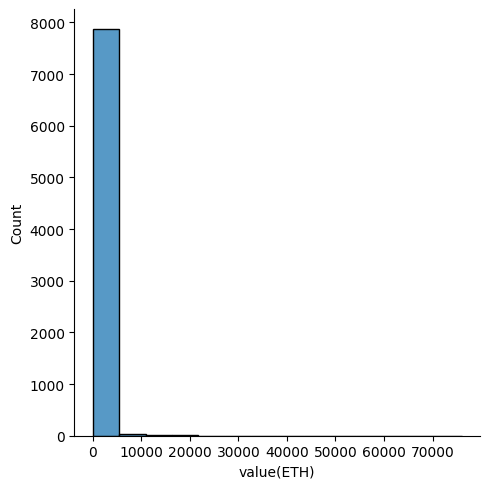

In [88]:
basic_research(df=df_api, col_name='value(ETH)')

we can see highly deviated distribution with High Kurtosis, to eliminate big outliers we can try to Log values to better see outliers

In [89]:
df_api['value(ETH)_log']

KeyError: 'value(ETH)_log'

In [ ]:
def take_log(value):
    if value == 0:
        result = value
    else:
        result = np.log(value)
    return result


df_api['value(ETH)_log'] = df_api['value(ETH)'].apply(lambda x: take_log(x))

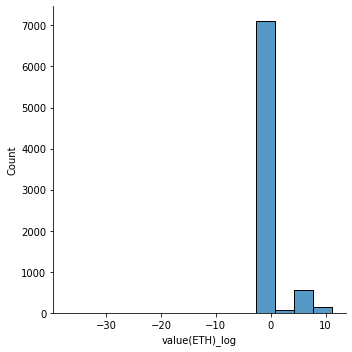

In [ ]:
sns.displot(df_api['value(ETH)_log'])

In [ ]:
# check results without zero transactions:
df_api_nozero = df_api[df_api['value(ETH)'] != 0]

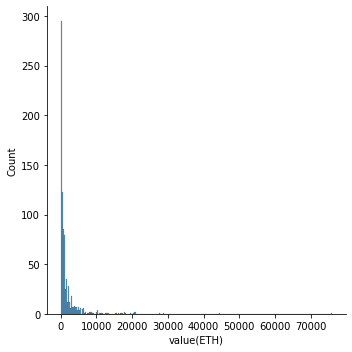

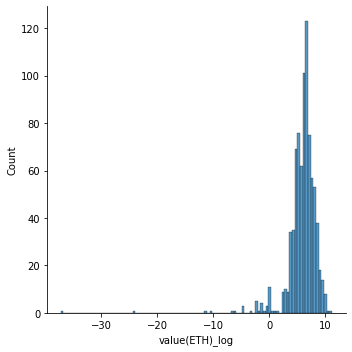

In [ ]:
sns.displot(df_api_nozero['value(ETH)'])
sns.displot(df_api_nozero['value(ETH)_log'])

we can see that even though, we have, many big outliers, log of value gives distribution look close to even Normal:

basic metrics:
count    831.000000
mean       5.927590
std        2.982019
min      -37.212425
25%        5.075174
50%        6.309918
75%        7.313220
max       11.238225
Name: value(ETH)_log, dtype: float64
-------------------------
Kurtosis (Эксцесс): 67.05647104482892
Skew (Ассиметрия): -5.938096873310502


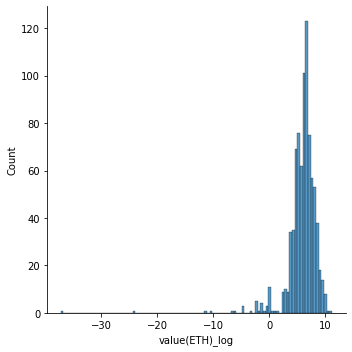

In [ ]:
basic_research(df=df_api_nozero, col_name='value(ETH)_log')

Kurtosis in that way is much lower, that good for handling Statistical test in the future

# Tableau  
[link_to_dashboard](https://public.tableau.com/app/profile/aleksei5255/viz/Transaction_Analytics_Ethrerscan/AddressAnalytics)

Let's look at the dynamics of ETH Flow:

![](./pic/ETH_flow.png)

Aggregating by month we can see that the Ouflow cashflow is indeed much higher for the address


In [ ]:
df.columns

Index(['Txhash', 'Blockno', 'UnixTimestamp', 'DateTime', 'From', 'To',
       'ContractAddress', 'Value_IN(ETH)', 'Value_OUT(ETH)',
       'CurrentValue @ $1084.99/Eth', 'TxnFee(ETH)', 'TxnFee(USD)',
       'Historical $Price/Eth', 'Method', 'CurrentValue @ $1103.42/Eth',
       'error_code', 'status', 'Value_IN(USD)', 'Value_OUT(USD)'],
      dtype='object')

Let's now take a look at the Balance history of the Address balance:

![](./pic/ehterscan_balance_graph.png)

we can see that the balance is usually small, except some points highs (top at more then 3 000 ETH!), it means that the address user probably invests in some assets and actively trade, so there is no free ETH on the balance, only small (in time) peaks when balance is high, probably due to transferring assets from one place to another or Swap (trade)

### Methods:  
lets now take a look at the methods. There are too many different methods presented, therefore for convenience we will take 6 biggest and all other methods name as "other":

![](./pic/3_ETH_flow_methods.png)

the highest in amount method is: "Transfer" majority of transactions are of that method and they are spread all over the time axis:

![](./pic/4_ETH_flow_methods_transfer.png)

##### Repay Behalf
- it about gasless transactions for users   
 
in normal transaction, user pay gas fees,  
in gasless transactions, we as developers pay gas for users transactions

![](./pic/5_repay_behalf.png)

since address is often does repay behalf, we might guess whether it is Developer or Application, which uses GasLess transactions

##### Zap in
- methods that shows us that the address provides liquidity into some of the Assets in Curve, Uniswap or Balancer probably

#### Mint  
- is the process of creating NFT (or may be other tockens), so this probably means that we were close to the Truth, when guessed that this address is belongs to the developer

# Conclusion  
Financial strategy of the Address is very Diverse:  
- Address Mints Tokens and therefore, probably Exchange them on ETH or other Assets
- Address Provides Service of GasLess transactions (pay for user transactions) (so it probably could be Smart Contracts Address)
- Address Trade Significant amount of Assests (but only in May of 2022) this could be new Business of the Address owner
- Address provides Liquidity, therefore earning Interest on it

# Analysis

In [ ]:
df['DateTime'][1]

1    2020-08-04 20:26:40
1    2021-06-01 02:11:53
Name: DateTime, dtype: object

test Jan-2021

In [93]:
df_jan_21 = pd.read_csv('./data/test/jan_2021.csv')

In [94]:
df_jan_21[(df_jan_21['Value_IN(ETH)'] != 0) | (df_jan_21['Value_OUT(ETH)'] != 0)]

,Txhash,Blockno,UnixTimestamp,DateTime,From,To,ContractAddress,Value_IN(ETH),Value_OUT(ETH),CurrentValue @ $1075.82/Eth,TxnFee(ETH),TxnFee(USD),Historical $Price/Eth,Status,ErrCode,Method,empty
30,0xdcc7b59f81fe431c06e346fde6d4cec8e8d591090451...,11570562,1609532224,2021-01-01 20:17:04,0xc098b2a3aa256d2140208c3de6543aaef5cd3a94,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,NaN,157.000000,0.000000,1.689037e+05,0.001181,1.270812,730.60,NaN,NaN,Transfer,NaN
32,0x60b59e16168d9cfba3cfd0e83e9bb80e1a9ea1d243da...,11570647,1609533262,2021-01-01 20:34:22,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,0x4ddc2d193948926d02f9b1fe9e1daa0718270ed5,NaN,0.000000,504.157428,5.423826e+05,0.007467,8.032987,730.60,NaN,NaN,Mint,NaN
169,0x9d42befc610455fe7c56c3dd73e892e355c7d87260d5...,11593088,1609830814,2021-01-05 07:13:34,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,NaN,1.000000,1.000000,1.075820e+03,0.002814,3.027357,1103.19,NaN,NaN,Transfer,NaN
229,0x09c8b266c0aec3fef27d5c74889285c86761ee5c09c0...,11607650,1610023737,2021-01-07 12:48:57,0xc333e80ef2dec2805f239e3f1e810612d294f771,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,NaN,50.000000,0.000000,5.379100e+04,0.002287,2.460293,1225.50,NaN,NaN,Transfer,NaN
237,0xb64d741fbaa9ef6220807e6f45a230c5b8354e5f383e...,11609096,1610042829,2021-01-07 18:07:09,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,0x67b66c99d3eb37fa76aa3ed1ff33e8e39f0b9c7a,NaN,0.000000,13122.199695,1.411712e+07,0.013838,14.887120,1225.50,NaN,NaN,Deposit,NaN
241,0xf149c6342c14c53cb5adcab6a72c1674eada0dfe1885...,11609111,1610043099,2021-01-07 18:11:39,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,0x67b66c99d3eb37fa76aa3ed1ff33e8e39f0b9c7a,NaN,0.000000,20237.255928,2.177164e+07,0.013763,14.806574,1225.50,NaN,NaN,Deposit,NaN
279,0x8d6b3145a31050161789546203fa06c9c7b2d01fc873...,11618217,1610163514,2021-01-09 03:38:34,0xc098b2a3aa256d2140208c3de6543aaef5cd3a94,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,NaN,1734.000000,0.000000,1.865472e+06,0.002818,3.031876,1279.96,NaN,NaN,Transfer,NaN
280,0xecd3dd10e9af27f82a824ec1a2a574682e4c106004ef...,11618278,1610164195,2021-01-09 03:49:55,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,0x3327172aaf91c7d073c3c959dedc4511b9bc8619,NaN,0.000000,1000.095000,1.075922e+06,0.002625,2.824028,1279.96,NaN,NaN,Transfer,NaN
283,0xbe8f8551f7acea588d677306928a6fc8201ade639510...,11622533,1610221556,2021-01-09 19:45:56,0x58f56615180a8eea4c462235d9e215f72484b4a3,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,NaN,0.211660,0.000000,2.277081e+02,0.001446,1.555203,1279.96,NaN,NaN,Transfer,NaN
284,0xb1a637dd0413d2e579fd1bd0b76b42951ec19675efcf...,11622630,1610222820,2021-01-09 20:07:00,0x99fd1378ca799ed6772fe7bcdc9b30b389518962,0x67b66c99d3eb37fa76aa3ed1ff33e8e39f0b9c7a,NaN,0.000000,726.600317,7.816912e+05,0.006007,6.462538,1279.96,NaN,NaN,Deposit,NaN
